# Khám phá trực quan dataset ChildSUn

Notebook này đọc dataset YOLO tại `data/childsun` (hỗ trợ cả nhãn detection và segmentation) và chỉ hiển thị kết quả trực tiếp trong Jupyter; không lưu ảnh hay biểu đồ ra đĩa.

In [1]:
from collections import Counter
from pathlib import Path
import random

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from PIL import Image

# Tự tìm thư mục gốc dự án, nên có thể chạy notebook từ Jupyter ở bất kỳ thư mục nào.
start = Path.cwd().resolve()
candidates = [start, *start.parents]
PROJECT_ROOT = next((p for p in candidates if (p / 'data' / 'childsun').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Không tìm thấy data/childsun. Hãy mở notebook bên trong project children-observer.')

DATASET_DIR = PROJECT_ROOT / 'data' / 'childsun'
SPLITS = ('train', 'val', 'test')
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
CLASS_NAMES = ['adult', 'child', 'knife', 'outlet', 'scissors']
COLORS = plt.cm.tab10(np.arange(len(CLASS_NAMES)))

print(f'Dataset: {DATASET_DIR}')
print('Classes:', ', '.join(CLASS_NAMES))

Dataset: D:\WORKSPACE\Project\children-observer\data\childsun
Classes: adult, child, knife, outlet, scissors


In [2]:
def read_yolo_label(label_path):
    """Chuẩn hoá nhãn YOLO detection/segmentation thành class_id, x_center, y_center, width, height."""
    if not label_path.exists():
        return []
    rows = []
    for line in label_path.read_text(encoding='utf-8').splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        try:
            values = list(map(float, parts))
        except ValueError:
            continue
        class_id = int(values[0])
        coordinates = values[1:]
        if len(coordinates) == 4:  # YOLO detection: x_center, y_center, width, height
            x_center, y_center, width, height = coordinates
        elif len(coordinates) >= 6 and len(coordinates) % 2 == 0:  # YOLO segmentation polygon
            xs, ys = coordinates[::2], coordinates[1::2]
            x_min, x_max = min(xs), max(xs)
            y_min, y_max = min(ys), max(ys)
            x_center, y_center = (x_min + x_max) / 2, (y_min + y_max) / 2
            width, height = x_max - x_min, y_max - y_min
        else:
            continue
        rows.append((class_id, x_center, y_center, width, height))
    return rows

records = []
for split in SPLITS:
    image_dir = DATASET_DIR / split / 'images'
    label_dir = DATASET_DIR / split / 'labels'
    for image_path in sorted(p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS):
        label_path = label_dir / f'{image_path.stem}.txt'
        labels = read_yolo_label(label_path)
        records.append({
            'split': split, 'image_path': image_path, 'label_path': label_path,
            'labels': labels, 'num_objects': len(labels), 'has_label_file': label_path.exists(),
        })

df = pd.DataFrame(records)
df.head()

,split,image_path,label_path,labels,num_objects,has_label_file
0,train,D:\WORKSPACE\Project\children-observer\data\ch...,D:\WORKSPACE\Project\children-observer\data\ch...,"[(4, 0.5, 0.4984375, 1.0, 0.678125)]",1,True
1,train,D:\WORKSPACE\Project\children-observer\data\ch...,D:\WORKSPACE\Project\children-observer\data\ch...,"[(4, 0.4921875, 0.496875, 0.95, 0.446875)]",1,True
2,train,D:\WORKSPACE\Project\children-observer\data\ch...,D:\WORKSPACE\Project\children-observer\data\ch...,"[(4, 0.503125, 0.490625, 0.7796875, 0.8703125)]",1,True
3,train,D:\WORKSPACE\Project\children-observer\data\ch...,D:\WORKSPACE\Project\children-observer\data\ch...,"[(4, 0.5109375, 0.3671875, 0.234375, 0.696875)]",1,True
4,train,D:\WORKSPACE\Project\children-observer\data\ch...,D:\WORKSPACE\Project\children-observer\data\ch...,"[(1, 0.5875, 0.5109375, 0.2109375, 0.778125), ...",2,True


In [3]:
# Tổng quan split, ảnh không có annotation và số bounding box.
summary = (df.groupby('split', sort=False)
           .agg(images=('image_path', 'size'), objects=('num_objects', 'sum'),
                images_without_label_file=('has_label_file', lambda x: (~x).sum()),
                images_with_no_objects=('num_objects', lambda x: (x == 0).sum()))
           .reindex(SPLITS))
summary.loc['total'] = summary.sum()
display(summary)

print(f"Tổng ảnh: {len(df):,} | Tổng bounding box: {int(df['num_objects'].sum()):,}")
print(f"Ảnh không có file nhãn: {(~df['has_label_file']).sum():,}")
print(f"Ảnh có file nhãn rỗng: {(df['num_objects'] == 0).sum():,}")

,images,objects,images_without_label_file,images_with_no_objects
split,,,,
train,7887,17598,0,165
val,2106,4468,0,59
test,1033,2157,0,22
total,11026,24223,0,246


Tổng ảnh: 11,026 | Tổng bounding box: 24,223
Ảnh không có file nhãn: 0
Ảnh có file nhãn rỗng: 246


,train,val,test,total
adult,2958,888,404,4250
child,5667,1540,841,8048
knife,3356,657,293,4306
outlet,2944,723,321,3988
scissors,2673,660,298,3631


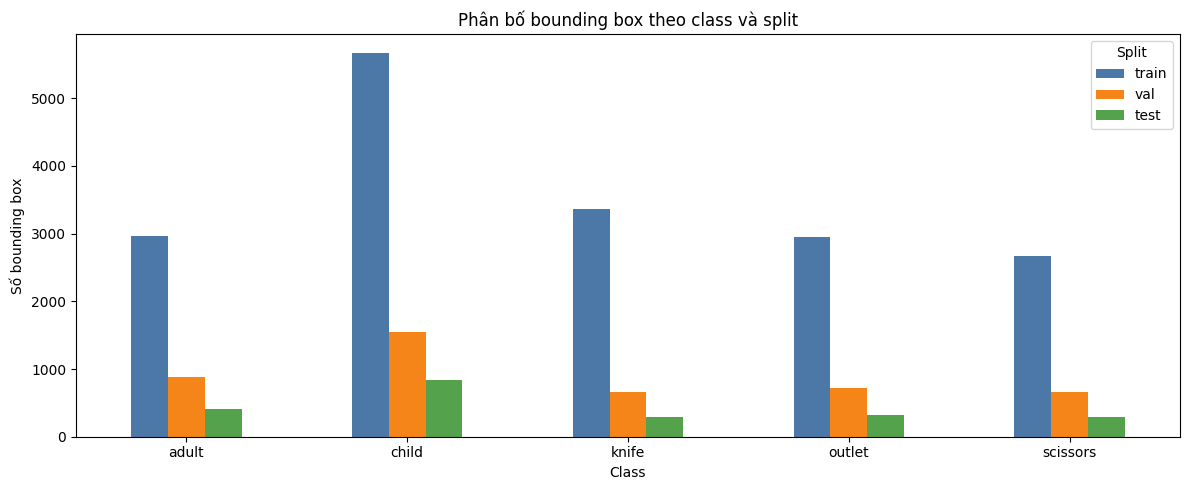

In [4]:
# Phân bố class theo từng split.
class_by_split = pd.DataFrame(0, index=CLASS_NAMES, columns=SPLITS)
for row in df.itertuples():
    for class_id, *_ in row.labels:
        if 0 <= class_id < len(CLASS_NAMES):
            class_by_split.loc[CLASS_NAMES[class_id], row.split] += 1

display(class_by_split.assign(total=class_by_split.sum(axis=1)))
ax = class_by_split.plot(kind='bar', figsize=(12, 5), color=['#4C78A8', '#F58518', '#54A24B'])
ax.set_title('Phân bố bounding box theo class và split')
ax.set_xlabel('Class')
ax.set_ylabel('Số bounding box')
ax.legend(title='Split')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

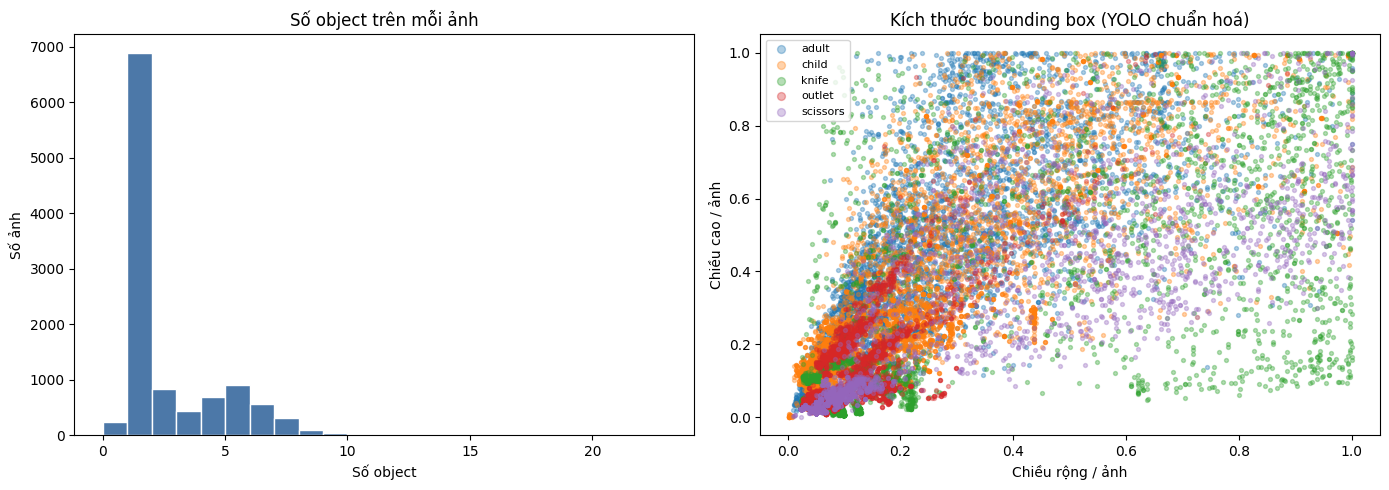

In [5]:
# Phân bố số object trên mỗi ảnh và kích thước bounding box (đã chuẩn hoá 0-1).
boxes = [(class_id, w, h) for labels in df.labels for class_id, _, _, w, h in labels
         if 0 <= class_id < len(CLASS_NAMES)]
box_df = pd.DataFrame(boxes, columns=['class_id', 'width', 'height'])
box_df['class'] = box_df['class_id'].map(dict(enumerate(CLASS_NAMES)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['num_objects'], bins=range(int(df['num_objects'].max()) + 2), color='#4C78A8', edgecolor='white')
axes[0].set_title('Số object trên mỗi ảnh')
axes[0].set_xlabel('Số object')
axes[0].set_ylabel('Số ảnh')

for class_id, class_name in enumerate(CLASS_NAMES):
    subset = box_df[box_df['class_id'] == class_id]
    axes[1].scatter(subset['width'], subset['height'], s=8, alpha=0.35, label=class_name, color=COLORS[class_id])
axes[1].set_title('Kích thước bounding box (YOLO chuẩn hoá)')
axes[1].set_xlabel('Chiều rộng / ảnh')
axes[1].set_ylabel('Chiều cao / ảnh')
axes[1].legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

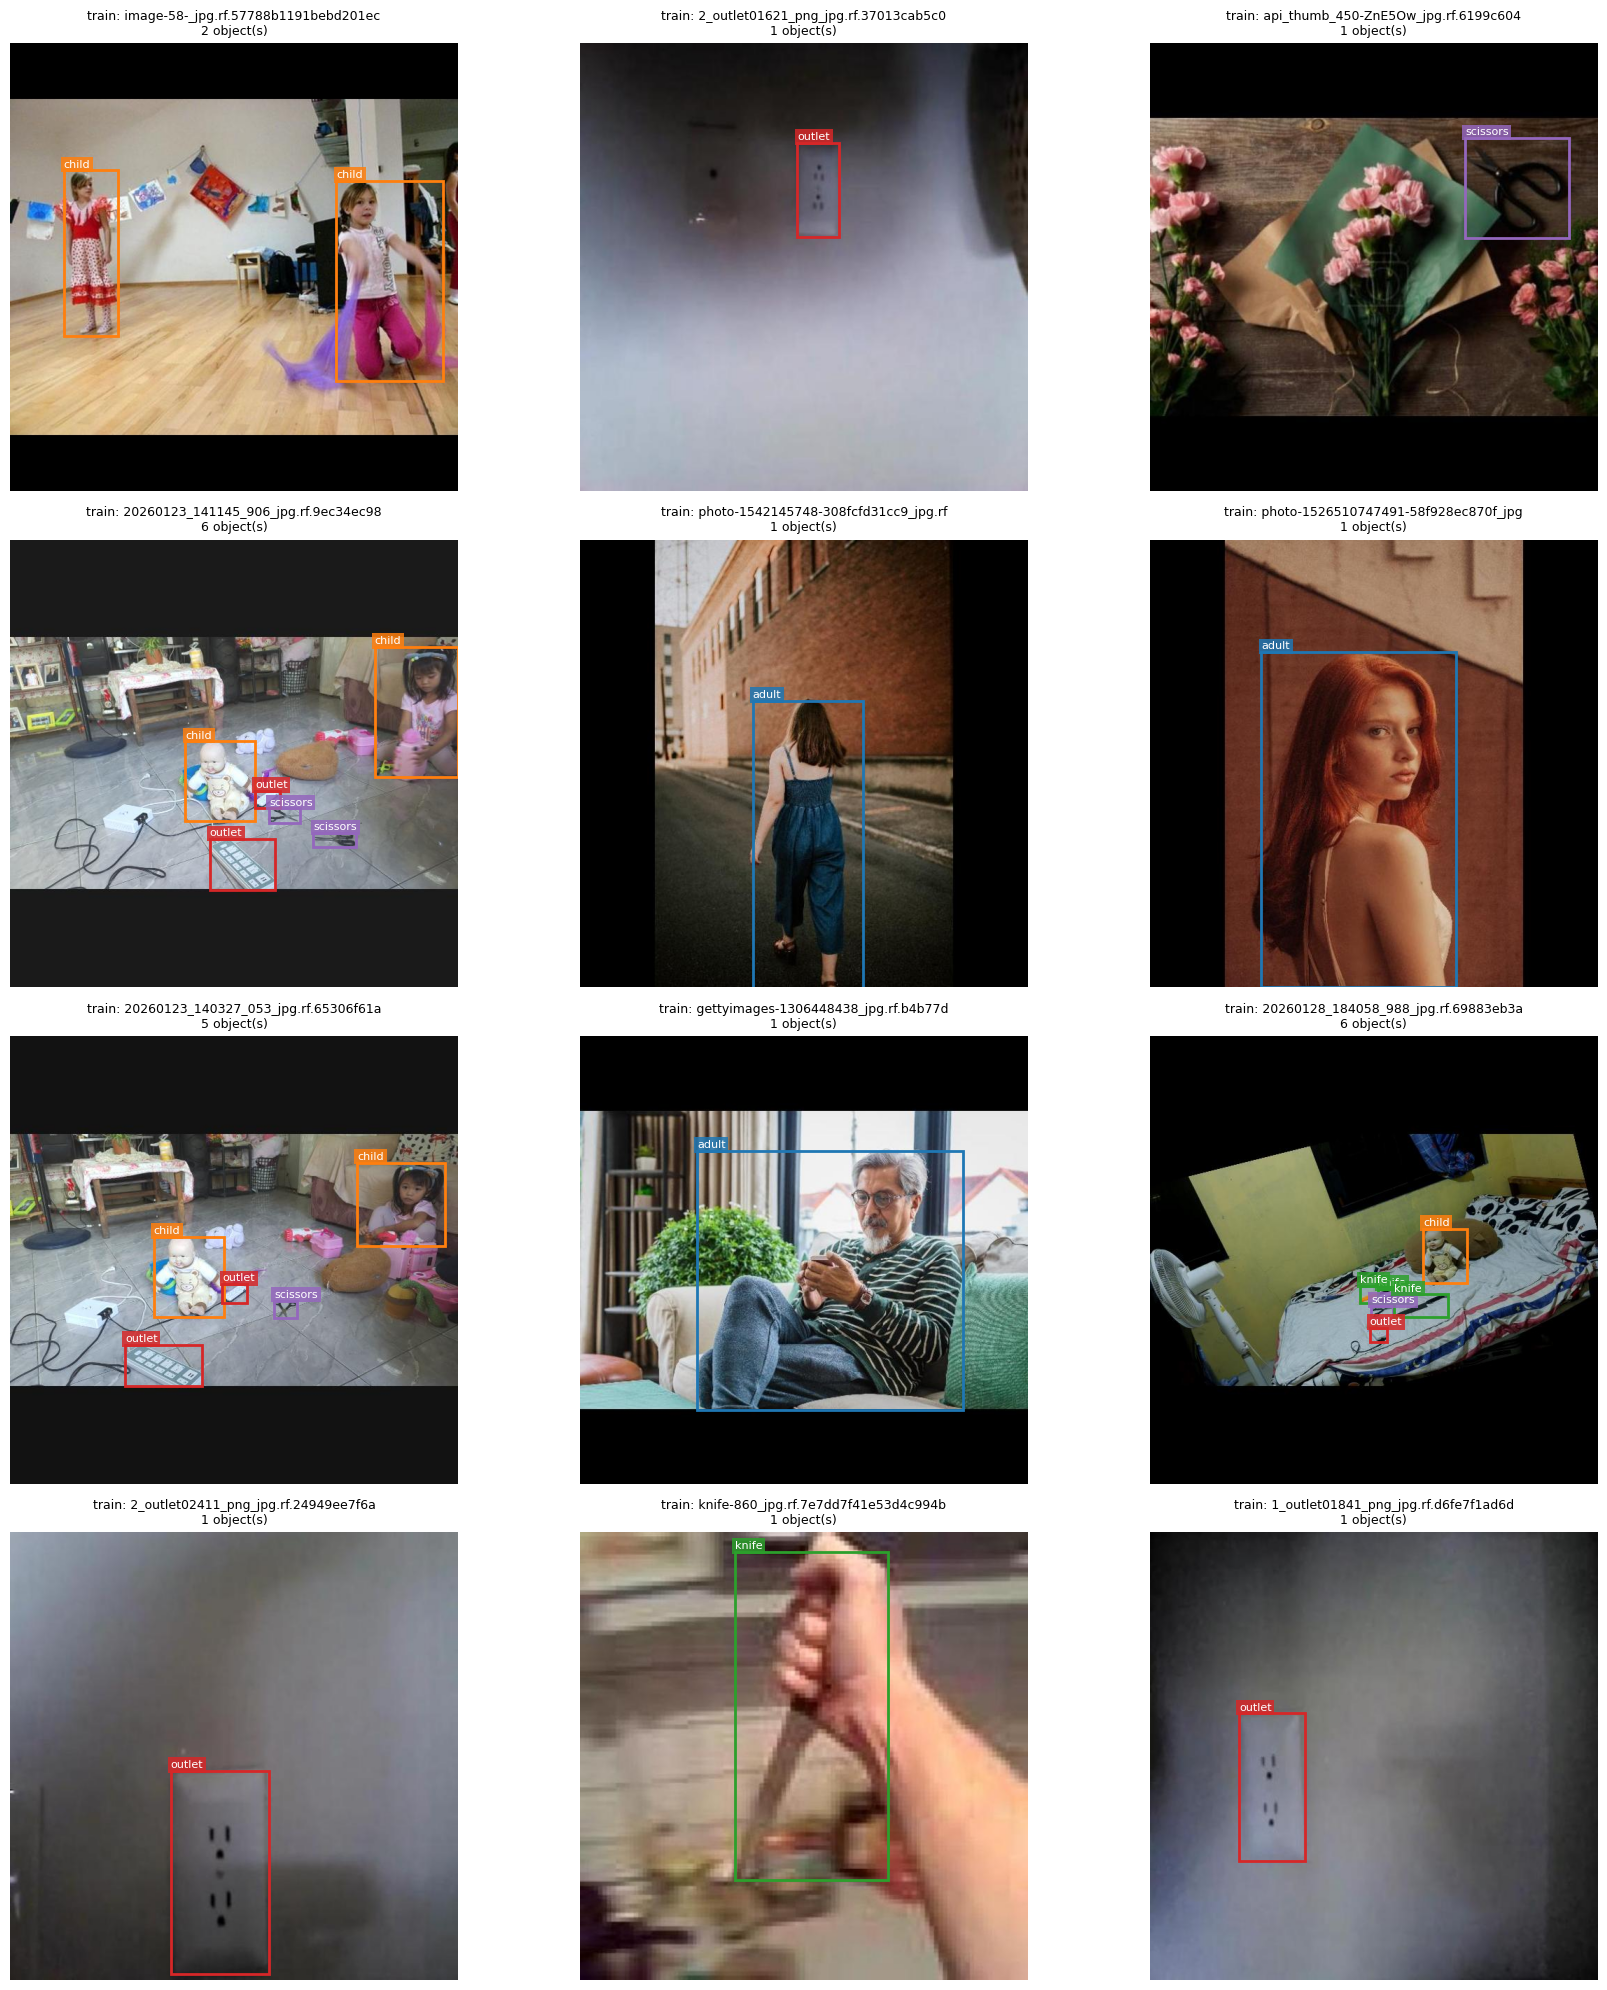

In [6]:
def draw_sample(ax, record):
    """Hiển thị ảnh và bounding box YOLO tương ứng."""
    image = np.asarray(Image.open(record.image_path).convert('RGB'))
    height, width = image.shape[:2]
    ax.imshow(image)
    for class_id, x_center, y_center, box_w, box_h in record.labels:
        if not 0 <= class_id < len(CLASS_NAMES):
            continue
        x = (x_center - box_w / 2) * width
        y = (y_center - box_h / 2) * height
        rect = patches.Rectangle((x, y), box_w * width, box_h * height,
                                 linewidth=2, edgecolor=COLORS[class_id], facecolor='none')
        ax.add_patch(rect)
        ax.text(x, max(y - 4, 10), CLASS_NAMES[class_id], color='white', fontsize=8,
                bbox={'facecolor': COLORS[class_id], 'alpha': 0.85, 'pad': 2, 'edgecolor': 'none'})
    ax.set_title(f"{record.split}: {record.image_path.name[:36]}\n{record.num_objects} object(s)", fontsize=9)
    ax.axis('off')

def show_samples(split='train', n=12, seed=42):
    """Chọn ngẫu nhiên n ảnh có nhãn từ split để kiểm tra annotation."""
    subset = df[(df['split'] == split) & (df['num_objects'] > 0)]
    if subset.empty:
        raise ValueError(f'Không có ảnh có nhãn trong split: {split}')
    samples = subset.sample(n=min(n, len(subset)), random_state=seed)
    cols = 3
    rows = int(np.ceil(len(samples) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    for ax, record in zip(np.ravel(axes), samples.itertuples()):
        draw_sample(ax, record)
    for ax in np.ravel(axes)[len(samples):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(split='train', n=12, seed=42)
# Thử thêm: show_samples('val', n=9, seed=7) hoặc show_samples('test', n=9, seed=7)

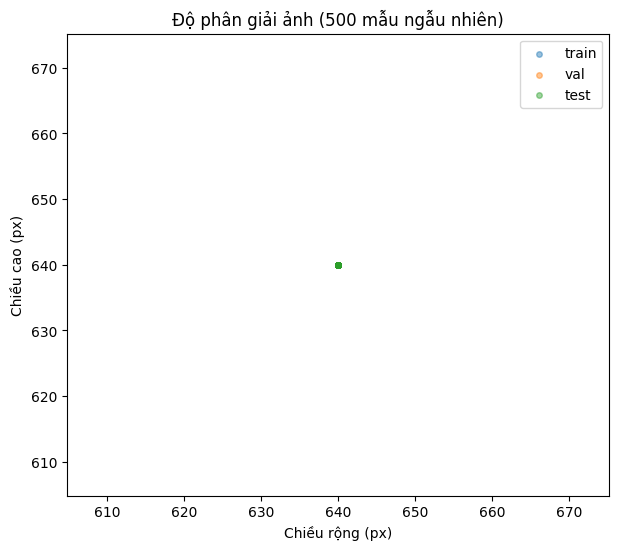

,width_px,height_px
count,500.0,500.0
mean,640.0,640.0
std,0.0,0.0
min,640.0,640.0
25%,640.0,640.0
50%,640.0,640.0
75%,640.0,640.0
max,640.0,640.0


In [7]:
# Xem nhanh độ phân giải ảnh bằng một mẫu ngẫu nhiên (tránh phải mở toàn bộ dataset).
N_DIMENSION_SAMPLES = min(500, len(df))
dimension_samples = df.sample(n=N_DIMENSION_SAMPLES, random_state=42).copy()
dimension_samples[['width_px', 'height_px']] = dimension_samples['image_path'].apply(
    lambda p: pd.Series(Image.open(p).size)
)

fig, ax = plt.subplots(figsize=(7, 6))
for split, group in dimension_samples.groupby('split', sort=False):
    ax.scatter(group['width_px'], group['height_px'], alpha=0.45, s=16, label=split)
ax.set_title(f'Độ phân giải ảnh ({N_DIMENSION_SAMPLES:,} mẫu ngẫu nhiên)')
ax.set_xlabel('Chiều rộng (px)')
ax.set_ylabel('Chiều cao (px)')
ax.legend()
plt.show()
display(dimension_samples[['split', 'width_px', 'height_px']].describe())